# 2 · plot — contact-prediction accuracy

Draws [`2_make_rprecision_data.ipynb`](2_make_rprecision_data.ipynb)'s table as one panel per
protein class. Edit `PREDICTORS` to choose which predictors appear and what they are called; the
dataset holds all of them.

In [1]:
# Run from anywhere: figlib lives next to this notebook.
import sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "figlib.py").exists() else Path("notebooks/figures")
sys.path.insert(0, str(HERE.resolve()))
import figlib

In [2]:
DATASET = "2_rprecision"
DPI = 300
# published name -> the label to draw. Order here is irrelevant (bars sort by value); membership
# is what matters. Both MarinFold checkpoints are shown by default: m2-p06 is the decontaminated
# one and the one Helico's contact arm used, the cooldown is the stronger but contaminated one.
# The #199 cooldown is deliberately absent: its training corpus was never filtered against
# FoldBench, so its number is not a claim we make. It is still in the dataset (#245 published it)
# and part 4 of the exploration notebook still contrasts the two — it simply is not drawn here.
PREDICTORS = {
    "Protenix-v2 + MSA": "Protenix-v2 + MSA",
    "ESMFold2": "ESMFold2",
    "ESMFold": "ESMFold",
    "#232 m2-p06 (decontaminated)": "MarinFold",
    "Protenix-v2 single-seq": "Protenix-v2, single sequence",
}
HIGHLIGHT = lambda predictor: predictor.startswith("#")   # noqa: E731 — drawn in the accent colour
metadata = figlib.describe(DATASET)

dataset      2_rprecision
made by      2_make_rprecision_data.ipynb
generated    2026-08-21T15:37:50+00:00
machine      ip1 · python 3.11.14 · NVIDIA RTX A5000 (23.7 GiB, cc 8.6)
checkout     fef976aa21de on exp250/evals-exploration-notebook  ** UNCOMMITTED CHANGES **
packages     marinfold 0.1.0, torch 2.5.1+cu121, transformers 4.57.6, numpy 2.4.6, pandas 3.0.5, matplotlib 3.11.1

parameters
   range                    all
   metric                   R
   classes                  {'natural': ['eval-val', 'eval-test'], 'designed': ['eval-denovo']}
   bootstrap_draws          2000
   bootstrap_seed           0

inputs
   2eb4f1fee148         97,519 B  https://huggingface.co/buckets/open-athena/MarinFold/resolve/data/contacts-v1-foldbench-monomers-exp245/eval_targets_foldbench_monomers.parquet
   b13d060a0912        199,548 B  https://huggingface.co/buckets/open-athena/MarinFold/resolve/data/contacts-v1-foldbench-monomers-exp245/eval_sets.csv
   b9670c354721        112,619 B  https://hug

--- designed · n=19 proteins ---


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/rprecision_designed.{png,pdf,svg} (300 dpi)


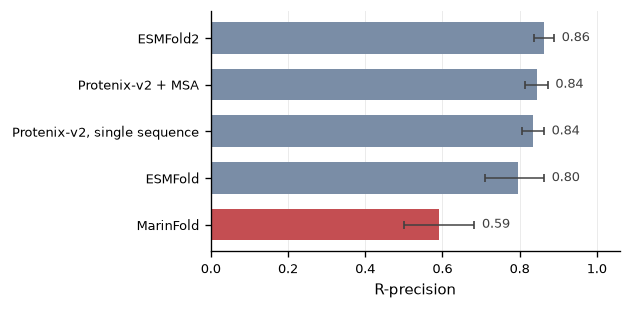

                       label  n  value  ci_low  ci_high
                   MarinFold 19  0.591   0.501    0.682
                     ESMFold 19  0.795   0.710    0.863
Protenix-v2, single sequence 19  0.835   0.806    0.863
           Protenix-v2 + MSA 19  0.844   0.813    0.873
                    ESMFold2 19  0.864   0.838    0.889
--- natural · n=314 proteins ---


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/rprecision_natural.{png,pdf,svg} (300 dpi)


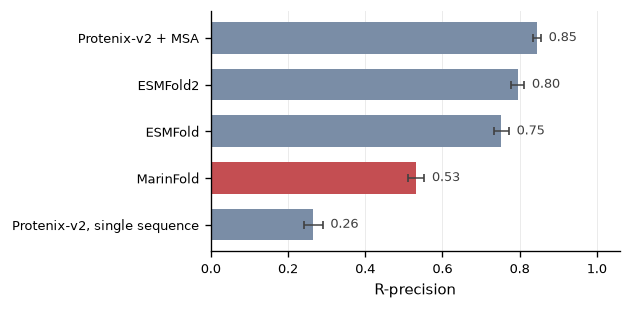

                       label   n  value  ci_low  ci_high
Protenix-v2, single sequence 314  0.264   0.240    0.290
                   MarinFold 314  0.532   0.512    0.553
                     ESMFold 314  0.752   0.733    0.772
                    ESMFold2 314  0.795   0.778    0.812
           Protenix-v2 + MSA 314  0.845   0.833    0.855


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

figlib.figure_style(DPI)
summary = pd.read_csv(figlib.require(DATASET, "summary.csv") / "summary.csv")
ACCENT, NEUTRAL = "#C44E52", "#7A8DA6"


def panel(frame, xlabel, name, highlight):
    """One horizontal bar per predictor, sorted, with its bootstrap interval and value."""
    frame = frame.sort_values("value")
    figure, axis = plt.subplots(figsize=(4.4, 0.34 * len(frame) + 0.9))
    axis.barh(frame.label, frame.value, height=0.68,
              color=[ACCENT if highlight(row) else NEUTRAL for row in frame.itertuples()],
              xerr=[frame.value - frame.ci_low, frame.ci_high - frame.value],
              error_kw=dict(ecolor="0.25", lw=0.9, capsize=2.5))
    for y, row in enumerate(frame.itertuples()):
        axis.text(row.ci_high + 0.02, y, f"{row.value:.2f}", va="center", fontsize=7.5,
                  color="0.25")
    axis.set(xlabel=xlabel, xlim=(0, 1.06))
    axis.grid(axis="x", alpha=0.25, lw=0.6)
    axis.set_axisbelow(True)
    figlib.save_figure(figure, name, DPI)
    plt.show()
    return frame


for protein_class in summary.protein_class.unique():
    frame = summary[(summary.protein_class == protein_class)
                    & summary.predictor.isin(PREDICTORS)].copy()
    frame["label"] = frame.predictor.map(PREDICTORS)
    print(f"--- {protein_class} · n={int(frame.n.iloc[0])} proteins ---")
    drawn = panel(frame, "R-precision", f"rprecision_{protein_class}",
                  lambda row: HIGHLIGHT(row.predictor))
    print(drawn[["label", "n", "value", "ci_low", "ci_high"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3f}"))